In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
import os

In [2]:
df=pd.read_csv("pre_final_database.csv")
df.shape

(5529, 37)

In [3]:
df.drop(columns=[#'sub_user',  ##As it has irrelevant data and very weak correlation with other table
                 'live_interview_credit', ##As it har irrelevant data and very weak correlation with other table
                 'pre_recorded_credit',
                 'ai_live_interview_credit',#As it has strong correlation 1
                 'referral_credit'], #has 200,400,600,44000==1 or 2, almost all are 0 and has strong correlation with ai_kit_count of 1
        inplace=True)
df.shape

(5529, 33)

In [4]:
df['company_size'] = pd.Categorical(df['company_size'], categories=['1-25', '26-100', '101-500', '500-1000', 'More than 1000'], ordered=True).codes
df = pd.get_dummies(df, columns=['jobma_catcher_otype', 'per_sub_user'], prefix=['otype', 'subuser'], drop_first=True)

df = df.astype({col: int for col in df.columns if df[col].dtype == 'bool'})
df['sub_user'] = df['sub_user'].apply(lambda x: 1000 if x > 1000 else x)      #To handele outlier

In [5]:
X = df.drop(['catcher_id'], axis=1).values
scaler = RobustScaler()
X = scaler.fit_transform(X)

In [6]:
# Split the data into training and test sets
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [7]:
X_train.shape, X_test.shape

((4423, 44), (1106, 44))

In [8]:
X_tensor = torch.tensor(X, dtype=torch.float32)

In [9]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Autoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent

In [10]:
# Model configuration
input_dim = X.shape[1]
latent_dim = 11
model = Autoencoder(input_dim, latent_dim)

# Optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Training loop
epochs = 300
for epoch in range(epochs):
    optimizer.zero_grad()
    reconstructed, latent = model(X_tensor)
    loss = criterion(reconstructed, X_tensor)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [20/300], Loss: 144719.2500
Epoch [40/300], Loss: 9280.9990
Epoch [60/300], Loss: 3716.6450
Epoch [80/300], Loss: 2032.6006
Epoch [100/300], Loss: 1587.7844
Epoch [120/300], Loss: 781.2601
Epoch [140/300], Loss: 516.3556
Epoch [160/300], Loss: 252.8645
Epoch [180/300], Loss: 162.2179
Epoch [200/300], Loss: 111.8702
Epoch [220/300], Loss: 47.7765
Epoch [240/300], Loss: 29.0598
Epoch [260/300], Loss: 25.3757
Epoch [280/300], Loss: 23.4602
Epoch [300/300], Loss: 21.3300


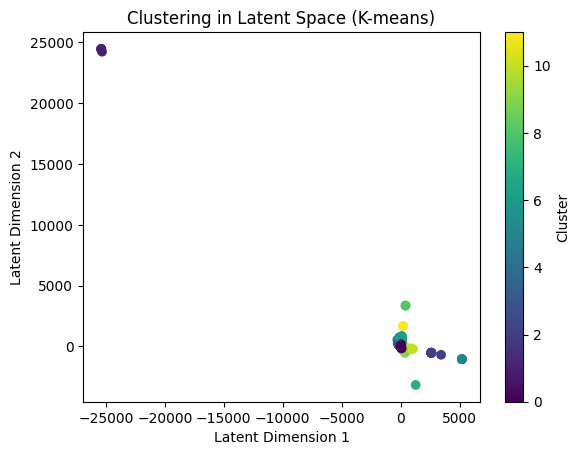

In [11]:
# Extract latent features
with torch.no_grad():
    latent_features = model.encoder(X_tensor).detach().numpy()

# Apply K-means clustering
kmeans = KMeans(n_clusters=12, random_state=42)
clusters = kmeans.fit_predict(latent_features)

# Visualize the clusters
plt.scatter(latent_features[:, 0], latent_features[:, 1], c=clusters, cmap='viridis', marker='o')
plt.title('Clustering in Latent Space (K-means)')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.colorbar(label='Cluster')
plt.show()

In [12]:
class ClusteringLayer(nn.Module):
    def __init__(self, n_clusters, latent_dim):
        super(ClusteringLayer, self).__init__()
        self.n_clusters = n_clusters
        self.latent_dim = latent_dim
        self.centroids = nn.Parameter(torch.Tensor(n_clusters, latent_dim))
        nn.init.xavier_uniform_(self.centroids)

    def forward(self, x):
        q = 1.0 / (1.0 + torch.sum((x.unsqueeze(1) - self.centroids) ** 2, dim=2))
        q = (q.t() / torch.sum(q, dim=1)).t()
        return q

In [13]:
class DEC(nn.Module):
    def __init__(self, autoencoder, clustering_layer):
        super(DEC, self).__init__()
        self.autoencoder = autoencoder
        self.clustering_layer = clustering_layer

    def forward(self, x):
        _, latent = self.autoencoder(x)
        q = self.clustering_layer(latent)
        return q, latent

In [14]:
def target_distribution(q):
    p = q ** 2 / q.sum(0)
    p = (p.t() / p.sum(1)).t()
    return p

# Initialize DEC model
n_clusters = 4
clustering_layer = ClusteringLayer(n_clusters, latent_dim)
dec_model = DEC(model, clustering_layer)

# Optimizer
optimizer = optim.Adam(dec_model.parameters(), lr=0.001)

# DEC training
epochs = 200
for epoch in range(epochs):
    optimizer.zero_grad()
    
    q, latent = dec_model(X_tensor)
    
    # Target distribution
    p = target_distribution(q).detach()
    
    # KL divergence loss
    loss = torch.nn.functional.kl_div(q.log(), p, reduction='batchmean')
    
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [20/200], Loss: 0.0553
Epoch [40/200], Loss: 0.0803
Epoch [60/200], Loss: 0.0929
Epoch [80/200], Loss: 0.1026
Epoch [100/200], Loss: 0.1294
Epoch [120/200], Loss: 0.1269
Epoch [140/200], Loss: 0.1361
Epoch [160/200], Loss: 0.1326
Epoch [180/200], Loss: 0.1281
Epoch [200/200], Loss: 0.1335


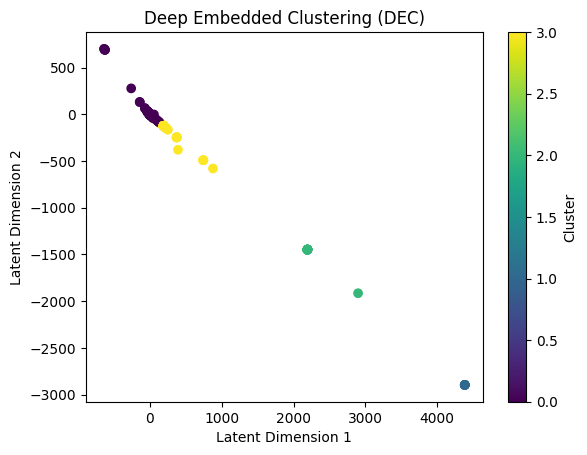

In [15]:
# Extract latent features
with torch.no_grad():
    _, latent_features = dec_model(X_tensor)

# Apply K-means clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(latent_features)

# Plot clusters
plt.scatter(latent_features[:, 0], latent_features[:, 1], c=clusters, cmap='viridis')
plt.title('Deep Embedded Clustering (DEC)')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.colorbar(label='Cluster')
plt.show()